X shape: (300, 2)  | y shape: (300,)  | classi: [0 1 2]


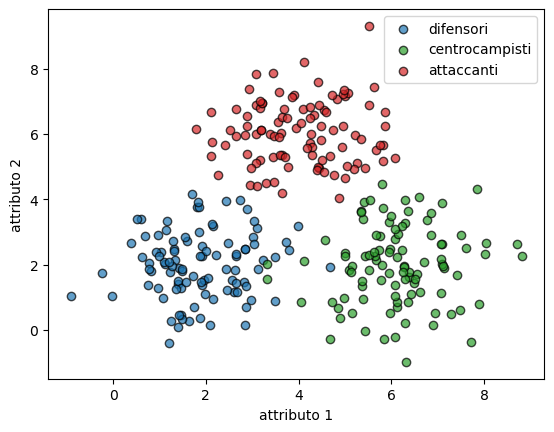

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
# 3 RUOLI (classi), 100 giocatori ciascuno, 2 feature
c0 = np.random.randn(100, 2)*1.0 + np.array([2, 2])   # ruolo 0
c1 = np.random.randn(100, 2)*1.0 + np.array([6, 2])   # ruolo 1
c2 = np.random.randn(100, 2)*1.0 + np.array([4, 6])   # ruolo 2
X = np.vstack([c0, c1, c2])
y = np.array([0]*100 + [1]*100 + [2]*100)             # etichette: 0, 1, 2

print("X shape:", X.shape, " | y shape:", y.shape, " | classi:", np.unique(y))

for k, col, nome in [(0,'#1f77b4','difensori'), (1,'#2ca02c','centrocampisti'), (2,'#d62728','attaccanti')]:
  plt.scatter(X[y==k,0], X[y==k,1], color=col, edgecolors='k', alpha=0.7, label=nome)
plt.xlabel("attributo 1"); plt.ylabel("attributo 2"); plt.legend(); plt.show()

In [3]:
# Aggiungo x0 = 1 -> X_b shape (300, 3)
m = X.shape[0]
K = 3                                    # numero di classi
X_b = np.hstack([np.ones((m, 1)), X])
print("X_b shape:", X_b.shape)

# Theta ORA È UNA MATRICE: una colonna per classe -> shape (n+1, K) = (3, 3)
Theta = np.zeros((3, K))
print("Theta shape:", Theta.shape)

# Z = X_b @ Theta -> (300, 3): Z[i,k] = punteggio della classe k per il giocatore i (= theta_k^T x_i)
# La SOFTMAX trasforma ogni RIGA di punteggi in 3 probabilità che sommano a 1:
def softmax(Z):
  Z = Z - Z.max(axis=1, keepdims=True)        # stabilità numerica (non cambia il risultato)
  e = np.exp(Z)
  return e / e.sum(axis=1, keepdims=True)

def ipotesi(X_b, Theta):
  return softmax(X_b @ Theta)                 # (300, 3): probabilità per ogni classe

# Con Theta = 0: tutti i punteggi sono 0 -> softmax dà [1/3, 1/3, 1/3] a tutti
P = ipotesi(X_b, Theta)
print("prime 3 righe di P:\n", P[:3].round(3))
print("somma di ogni riga:", P[:3].sum(axis=1).round(3))

X_b shape: (300, 3)
Theta shape: (3, 3)
prime 3 righe di P:
 [[0.333 0.333 0.333]
 [0.333 0.333 0.333]
 [0.333 0.333 0.333]]
somma di ogni riga: [1. 1. 1.]


In [4]:
# Prima serve il one-hot: trasformo l'etichetta (0, 1 o 2) in un vettore con un 1 sulla classe vera.

# One-hot: T shape (300, 3).  T[i, classe_vera] = 1, il resto 0.
T = np.zeros((m, K))
T[np.arange(m), y] = 1
print("primi 3 y:", y[:3], "  -> one-hot:\n", T[:3])

# Cross-entropy: guarda SOLO la probabilità assegnata alla classe VERA.
#   J = -(1/m) * somma_i  log( P[i, classe_vera_i] )
def cross_entropy(P, T):
  return -np.mean(np.sum(T * np.log(P + 1e-12), axis=1))

P = ipotesi(X_b, Theta)
print("cross-entropy iniziale (Theta=0):", round(cross_entropy(P, T), 4))

primi 3 y: [0 0 0]   -> one-hot:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
cross-entropy iniziale (Theta=0): 1.0986


In [5]:
Theta = np.zeros((3, K))
alpha, epoche = 0.1, 60

for epoca in range(epoche):
  for i in np.random.permutation(m):
      x_i = X_b[i:i+1]                  # (1, 3)
      t_i = T[i:i+1]                    # (1, 3) one-hot
      P_i = ipotesi(x_i, Theta)        # (1, 3) probabilità predette
      gradiente = x_i.T @ (P_i - t_i)  # (3, 3)   <- (P - T) x
      Theta = Theta - alpha * gradiente

  if epoca % 10 == 0 or epoca == epoche - 1:
      P = ipotesi(X_b, Theta)
      acc = np.mean(P.argmax(axis=1) == y) * 100
      print(f"epoca {epoca:2d} -> cross-entropy={cross_entropy(P, T):.3f}  acc={acc:.0f}%")

epoca  0 -> cross-entropy=0.360  acc=85%
epoca 10 -> cross-entropy=0.170  acc=93%
epoca 20 -> cross-entropy=0.073  acc=98%
epoca 30 -> cross-entropy=0.102  acc=95%
epoca 40 -> cross-entropy=0.076  acc=97%
epoca 50 -> cross-entropy=0.056  acc=99%
epoca 59 -> cross-entropy=0.100  acc=96%


probabilità: [[0. 1. 0.]]  -> ruolo predetto: 1
accuracy: 96 %


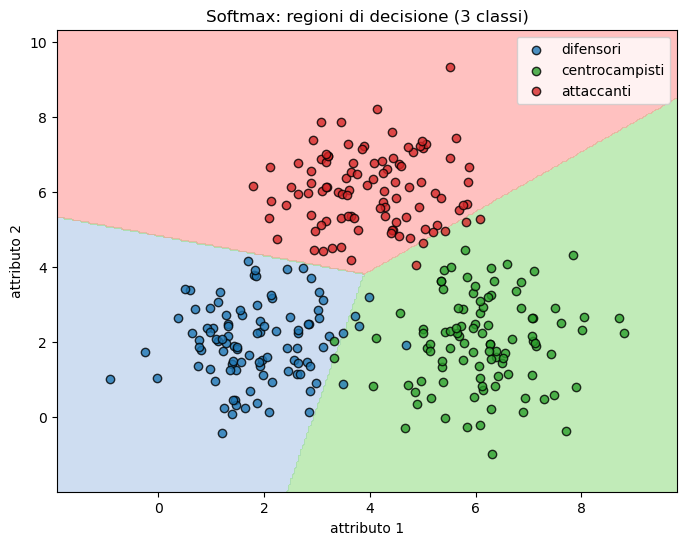

In [6]:
# Predizione per un giocatore nuovo (attributo1 = 5, attributo2 = 2)
nuovo = np.array([[1.0, 5.0, 2.0]])          # [x0=1, attr1, attr2]
prob = ipotesi(nuovo, Theta)
print("probabilità:", prob.round(3), " -> ruolo predetto:", int(prob.argmax()))

# Accuracy
P = ipotesi(X_b, Theta)
print("accuracy:", round(float((P.argmax(axis=1) == y).mean()*100)), "%")

# Regioni di decisione: coloro il piano in base alla classe VINCENTE (argmax)
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                   np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
griglia = np.c_[np.ones(xx.size), xx.ravel(), yy.ravel()]
zone = ipotesi(griglia, Theta).argmax(axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zone, levels=[-0.5,0.5,1.5,2.5],
           colors=['#aec7e8','#98df8a','#ff9896'], alpha=0.6)
for k, col, nome in [(0,'#1f77b4','difensori'), (1,'#2ca02c','centrocampisti'), (2,'#d62728','attaccanti')]:
  plt.scatter(X[y==k,0], X[y==k,1], color=col, edgecolors='k', alpha=0.8, label=nome)
plt.xlabel("attributo 1"); plt.ylabel("attributo 2")
plt.title("Softmax: regioni di decisione (3 classi)"); plt.legend(); plt.show()